# Chapter 16: Quantum Phase Estimation

Quantum Phase Estimation (QPE) algorithm.

---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions


In [1]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import UnitaryGate
from qiskit.circuit.library import  HamiltonianGate
from qiskit.synthesis import LieTrotter, SuzukiTrotter
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Statevector, Operator
from qiskit.quantum_info import SparsePauliOp
from Chapter17_QPE_functions import (myQPESingleBit, myQPEMultiBit,
    QiskitQPEWrapper, hamiltonianPhaseEstimationDemo, laplacian1D,
    laplacianEigenExact, laplacianEigenvector,
    estimateEigenvalueQPE)

print('Setup complete!')

Setup complete!


## Hamiltonian

[[-0.25+0.4330127j  0.75+0.4330127j]
 [ 0.75+0.4330127j -0.25+0.4330127j]]


<IPython.core.display.Latex object>

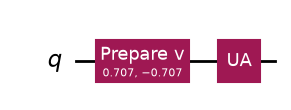

In [2]:
A = np.array([[2,-1],[-1,2]])
f = 0.5
lambdaUpper = 3
t = -2*np.pi*f/lambdaUpper #Note negative
U_A = HamiltonianGate(A, time=t,label = 'UA')
print(np.array(U_A.to_matrix()))
v = np.array([1/np.sqrt(2),-1/np.sqrt(2)])
circuit = QuantumCircuit(1)
circuit.prepare_state(Statevector(v) ,0,'Prepare v')
circuit.append(U_A, qargs=[0])
psi = Statevector(circuit)
display(psi.draw('latex'))
circuit.draw('mpl') 

## Control gate

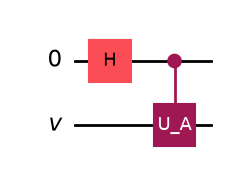

In [3]:
zeroQubit = QuantumRegister(1, '0')
vQubit = QuantumRegister(1, 'v')
circuit = QuantumCircuit(zeroQubit,vQubit) 
circuit.h(0)
UMatrix = 1/np.sqrt(2)*np.array([[1,1],[1j,-1j]]) 
U = UnitaryGate(UMatrix,'U_A')
UControl = U.control(1)
circuit.append(UControl,[0,1])
circuit.draw('mpl') 

## Probability Model

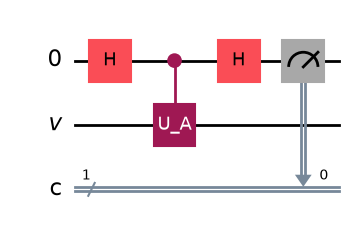

In [4]:
zeroQubit = QuantumRegister(1, '0')
vQubit = QuantumRegister(1, 'v')
cBit = ClassicalRegister(1, 'c')
circuit = QuantumCircuit(zeroQubit,vQubit,cBit) 
circuit.h(0)
UMatrix = 1/np.sqrt(2)*np.array([[1,1],[1j,-1j]]) 
U = UnitaryGate(UMatrix,'U_A')
UControl = U.control(1)
circuit.append(UControl,[0,1])
circuit.h(0)
circuit.measure([0], [0]) 
circuit.draw('mpl') 


### Example 1

In [5]:
A = np.array([[1,0],[0,0.75]])
v = np.array([1,0])
lambdaUpper = 2

[thetaEstimates,probabilities] = myQPESingleBit(A,v,lambdaUpper,nShots=1000)
print("Theta estimates:", thetaEstimates)
print("Probabilities:", probabilities)

Counts: {'1': 1000}
Theta estimates: [0.5]
Probabilities: [1.]


### Example 2

In [6]:
A = np.array([[1,0],[0,0.75]])
v = np.array([0,1])
lambdaUpper = 2

[thetaEstimates,probabilities] = myQPESingleBit(A,v,lambdaUpper,nShots=1000)
print("Theta estimates:", thetaEstimates)
print("Probabilities:", probabilities)

Counts: {'1': 852, '0': 148}
Theta estimates: [0.5 0. ]
Probabilities: [0.852 0.148]


## Multiple digit QPE 

### Multibit Example 1

In [7]:
A = np.array([[1,0],[0,0.75]])
v = np.array([0,1])
lambdaUpper = 2
nThetaBits = 2

[thetaEstimates,probabilities] = myQPEMultiBit(A,v,lambdaUpper,m = nThetaBits, nShots=1000)
thetaTilde = np.sum(thetaEstimates*probabilities)
print("Theta estimates:", thetaEstimates)
print("Probabilities:", probabilities)
print("thetaTilde: ", thetaTilde)

{'10': 420, '00': 71, '01': 435, '11': 74}
Theta estimates: [0.25 0.5  0.75 0.  ]
Probabilities: [0.435 0.42  0.074 0.071]
thetaTilde:  0.37424999999999997


### Multibit Example 2

In [8]:
nThetaBits = 3

[thetaEstimates,probabilities] = myQPEMultiBit(A,v,lambdaUpper,m = nThetaBits, nShots=1000)
thetaTilde = np.sum(thetaEstimates*probabilities)
print("Theta estimates:", thetaEstimates)
print("Probabilities:", probabilities)
print("thetaTilde: ", thetaTilde)

{'011': 1000}
Theta estimates: [0.375]
Probabilities: [1.]
thetaTilde:  0.375


### Multibit Example 3

In [9]:
nThetaBits = 5

[thetaEstimates,probabilities] = myQPEMultiBit(A,v,lambdaUpper,m = nThetaBits, nShots=1000)
thetaTilde = np.sum(thetaEstimates*probabilities)
print("Theta estimates:", thetaEstimates)
print("Probabilities:", probabilities)
print("thetaTilde: ", thetaTilde)

{'01100': 1000}
Theta estimates: [0.375]
Probabilities: [1.]
thetaTilde:  0.375


## Qiskit QPE Wrapper

## QPE Example 1

In [10]:
A = np.array([[1,0],[0,0.75]])
v0 = np.array([0,1])
v1 = np.array([1,0])
Lambda = [0.75,1]
a = [1/np.sqrt(2),1/np.sqrt(2)]
a= [0,1]
v = a[0]*v0 + a[1]*v1
lambdaUpper = 2
m = 1




## QPE Example 2

In [11]:
A = np.array([[2,-1],[-1,2]])
v0 = np.array([1/np.sqrt(2),1/np.sqrt(2)])
v1 = np.array([1/np.sqrt(2),-1/np.sqrt(2)])
Lambda = [1,3]
a = [1,0]
v = a[0]*v0 + a[1]*v1
lambdaUpper = 6
m = 4



## QPE Example 3

In [12]:
A = np.array([[1,0,0,-0.5],[0,1,0,0],[0,0,1,0],[-0.5,0,0,1]])
v0 = np.array([1/np.sqrt(2),0,0,1/np.sqrt(2)])
v1 = np.array([0,1,0,0])
v2 = np.array([0,0,1,0])
v3 = np.array([1/np.sqrt(2),0,0,-1/np.sqrt(2)])
Lambda = [0.5,1,1,1.5]
#a = [1/np.sqrt(4),1/np.sqrt(4),1/np.sqrt(4),1/np.sqrt(4)]
a = [0,0,1,0]
v = a[0]*v0 + a[1]*v1 + a[2]*v2 + a[3]*v3
lambdaUpper = 3
m = 2
[thetaEstimates,P] = myQPESingleBit(A,v,lambdaUpper)	
print("thetaEstimates:",thetaEstimates)
print("probabilities:", P)
thetaTilde = np.sum(thetaEstimates*P)
print("thetaTilde:", thetaTilde)
print("EigenvalueTilde:",thetaTilde*lambdaUpper)

Counts: {'0': 242, '1': 758}
thetaEstimates: [0.  0.5]
probabilities: [0.242 0.758]
thetaTilde: 0.379
EigenvalueTilde: 1.137


In [13]:
m = 3
A = np.array([[2,-1,0,0],[-1,2,-1,0],[0,-1,2,-1],[0,0,-1,2]])
v = np.random.rand(4)
v = v/np.linalg.norm(v)
f = 0.5
lambdaUpper = 4



## Trotterization error

In [14]:
# Pauli matrices
Z = np.array([[1, 0], [0, -1]])
X = np.array([[0, 1], [1, 0]])
 
# A = 2Z - 0.5X
A = 2*Z - 0.5*X
A1 = 2*Z
A2 = -0.5*X
 
lambdaUpper = 5
t = 2*np.pi/lambdaUpper
 
# Exact Hamiltonian
U_exact = expm(1j*A*t)
 
# Trotter convergence (first-order only)
for r in [1, 2, 5, 10, 50, 100]:
    dt = t / r
    step1 = expm(1j * A1 * dt) @ expm(1j * A2 * dt)
    U_trotter1 = np.linalg.matrix_power(step1, r)
    err1 = np.linalg.norm(U_exact - U_trotter1)
    print(f"r={r:3d}: 1st-order err={err1:.6f}")

# Trotter convergence (second-order only)
for r in [1, 2, 5, 10, 50, 100]:
    dt = t / r
    step2 = expm(1j * A1 * dt / 2) @ expm(1j * A2 * dt) @ expm(1j * A1 * dt / 2)
    U_trotter2 = np.linalg.matrix_power(step2, r)
    err2 = np.linalg.norm(U_exact - U_trotter2)
    print(f"r={r:3d}: 2nd-order err={err2:.6f}")

r=  1: 1st-order err=1.022180
r=  2: 1st-order err=0.268470
r=  5: 1st-order err=0.092678
r= 10: 1st-order err=0.045427
r= 50: 1st-order err=0.009028
r=100: 1st-order err=0.004513
r=  1: 2nd-order err=0.710502
r=  2: 2nd-order err=0.091288
r=  5: 2nd-order err=0.012592
r= 10: 2nd-order err=0.003087
r= 50: 2nd-order err=0.000123
r=100: 2nd-order err=0.000031


### Qiskit Trotterization

In [15]:
# A = 2Z - 0.5X
A = np.array([[2, -0.5], [-0.5, -2]])
lambdaUpper = 5
t = 2*np.pi/lambdaUpper

# Exact Hamiltonian
U_exact = expm(1j*A*t)

# Pauli decomposition
H_pauli = SparsePauliOp.from_list([('Z', 2.0), ('X', -0.5)])

# First-order Trotter
for r in [1, 2, 5, 10, 50]:
    synth = LieTrotter(reps=r)
    evo = PauliEvolutionGate(H_pauli, time=-t, synthesis=synth)
    qc = QuantumCircuit(1)
    qc.append(evo, [0])
    U_trot = np.array(Operator(qc.decompose()))
    print(f"r={r:2d}: 1st-order err = "
          f"{np.linalg.norm(U_exact - U_trot):.6f}")

# Second-order Trotter
for r in [1, 2, 5, 10, 50]:
    synth = SuzukiTrotter(order=2, reps=r)
    evo = PauliEvolutionGate(H_pauli, time=-t, synthesis=synth)
    qc = QuantumCircuit(1)
    qc.append(evo, [0])
    U_trot = np.array(Operator(qc.decompose()))
    print(f"r={r:2d}: 2nd-order err = "
          f"{np.linalg.norm(U_exact - U_trot):.6f}")

r= 1: 1st-order err = 1.022180
r= 2: 1st-order err = 0.268470
r= 5: 1st-order err = 0.092678
r=10: 1st-order err = 0.045427
r=50: 1st-order err = 0.009028
r= 1: 2nd-order err = 0.710502
r= 2: 2nd-order err = 0.091288
r= 5: 2nd-order err = 0.012592
r=10: 2nd-order err = 0.003087
r=50: 2nd-order err = 0.000123


## Qiskit `HamiltonianPhaseEstimation`
Hand Qiskit the **Hermitian matrix A itself**; it scales and Trotterizes internally. The `evolution` argument is the Trotter knob — the **default is a single first-order step**, the least accurate case.

In [16]:
# HamiltonianPhaseEstimation on A = 2Z - 0.5X (exact top eigenvalue 2.0616).
# The default first-order/1-step evolution is biased; a 2nd-order Trotter
# (or more reps) removes the error.  Requires the qiskit-algorithms package.
from qiskit.synthesis import LieTrotter, SuzukiTrotter

A = np.array([[2., -0.5], [-0.5, -2.]])          # = 2Z - 0.5X
w, V = np.linalg.eigh(A); vTop = V[:, int(np.argmax(w))]

for evo, label in [(None,                        'default (1st-order, 1 step)'),
                   (LieTrotter(reps=20),          'LieTrotter reps=20'),
                   (SuzukiTrotter(order=2, reps=8),'SuzukiTrotter order=2 reps=8')]:
    res = hamiltonianPhaseEstimationDemo(A, vTop, bound=3.0, m=8, evolution=evo)
    print(f'{label:32s} -> {res.most_likely_eigenvalue.real:+.4f} (exact {w.max():.4f})')

default (1st-order, 1 step)      -> +1.9219 (exact 2.0616)
LieTrotter reps=20               -> +2.0625 (exact 2.0616)
SuzukiTrotter order=2 reps=8     -> +2.0625 (exact 2.0616)


## Example: a discrete Laplacian
QPE applies unchanged to a matrix engineers recognize — the 1D Laplacian, whose spectrum is known in closed form (used here only to check). The fundamental is the smallest eigenvalue, hence the smallest phase and the hardest to resolve.

In [17]:
# Fundamental mode of the 1D Dirichlet Laplacian via QPE.
N = 4                                   # N = 2**n
A = laplacian1D(N)                      # tridiag(-1, 2, -1)
print('exact spectrum:', np.round(laplacianEigenExact(N), 4))

v0 = laplacianEigenvector(N, 0)         # analytic fundamental mode (sine)
peak, weighted = estimateEigenvalueQPE(A, v0, lambdaUpper=4.0, m=8)
print(f'fundamental via QPE: peak={peak:.4f}  weighted={weighted:.4f}  '
      f'exact={laplacianEigenExact(N)[0]:.4f}')

exact spectrum: [0.382 1.382 2.618 3.618]
fundamental via QPE: peak=0.3750  weighted=0.3966  exact=0.3820


### One QPE run reads the whole spectrum
Feed an equal-weight superposition of all four modes: a single QPE run returns every eigenvalue at once, each with weight $|b^k|^2\approx0.25$. An $N$-dim system has at most $N$ eigenvalues, so we keep the $N$ most probable bins and take `min` for $\lambda^0$ (the bound HHL needs). But a faint real eigenvalue is indistinguishable from spectral leakage, so no fixed cutoff is principled — the same reason HHL's lower bound is only approximate.

In [18]:
# Equal-weight superposition of all modes -> one QPE run reads the whole spectrum.
b = sum(laplacianEigenvector(N, k) for k in range(N))
b = b / np.linalg.norm(b)
theta, P = myQPEMultiBit(A, b, lambdaUpper=4.0, m=8)
topN = theta[np.argsort(P)[-N:]]            # an N-dim system has <= N eigenvalues
print('recovered lambda:', np.round(np.sort(topN * 4.0), 3))
print('exact spectrum  :', np.round(laplacianEigenExact(N), 3))
print('lambda_min =', round(min(topN) * 4.0, 4))

{'01010100': 1, '00011000': 113, '01010101': 4, '00011001': 84, '11100101': 4, '10101001': 4, '11101000': 121, '01011000': 134, '11110010': 1, '00010111': 7, '10100111': 85, '00010101': 3, '01011001': 79, '11101001': 11, '01010111': 13, '11001111': 1, '11100100': 1, '10101000': 142, '00001100': 2, '11101111': 2, '01101000': 1, '01011010': 21, '10110000': 2, '11110100': 1, '00010001': 1, '10101100': 1, '11100111': 70, '00001101': 1, '11101010': 4, '00101100': 1, '00000011': 1, '11001101': 1, '11100110': 4, '11100011': 1, '00000110': 1, '01000000': 1, '10100000': 2, '10010011': 1, '00001011': 1, '00100010': 1, '11001001': 1, '10100110': 8, '00011010': 9, '01011011': 2, '11101101': 2, '01001111': 1, '00100000': 2, '10101101': 2, '00010110': 8, '10110010': 1, '00011101': 1, '01011100': 2, '00001110': 1, '10010100': 1, '10001000': 1, '00011100': 3, '01010000': 1, '10101010': 5, '10011111': 1, '11100010': 1, '10001010': 1, '01010110': 4, '00011011': 2, '01100101': 1, '10101011': 2, '00011111